## Transmission Line Fault Detection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# This cell is now redundant as its content has been moved to cell ac5ec4f0.

In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/TLFaultDataset.csv'
df = pd.read_csv(file_path)

print("DataFrame 'df' loaded successfully.")
#print(f"Dataset shape: {df.shape}")
#display(df.head())

DataFrame 'df' loaded successfully.


### 1. Initial Data Inspection

In [ ]:
print(f"Dataset shape: {df.shape}")
display(df.info())

Dataset shape: (578923, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578923 entries, 0 to 578922
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Number          578923 non-null  float64
 1   IaL12           578923 non-null  float64
 2   IbL12           578923 non-null  float64
 3   IcL12           578923 non-null  float64
 4   Ia13            578923 non-null  float64
 5   Ib13            578923 non-null  float64
 6   Ic13            578923 non-null  float64
 7   Ia23            578923 non-null  float64
 8   Ib23            578923 non-null  float64
 9   Ic23            578923 non-null  float64
 10  Ia24            578923 non-null  float64
 11  Ib24            578923 non-null  float64
 12  Ic24            578923 non-null  float64
 13  Ia25            578923 non-null  float64
 14  Ib25            578923 non-null  float64
 15  Ic25            578923 non-null  float64
 16  Ia34            578923 non-n

None

### 2. Descriptive Statistics

In [ ]:
display(df.describe())

,Number,IaL12,IbL12,IcL12,Ia13,Ib13,Ic13,Ia23,Ib23,Ic23,...,Vc24,Va25,Vb25,Vc25,Va34,Vb34,Vc34,Va45,Vb45,Vc45
count,578923.000000,5.789230e+05,5.789230e+05,5.789230e+05,578923.000000,578923.000000,5.789230e+05,5.789230e+05,5.789230e+05,5.789230e+05,...,5.789230e+05,578923.000000,578923.000000,5.789230e+05,5.789230e+05,5.789230e+05,5.789230e+05,578923.000000,578923.000000,5.789230e+05
mean,0.456009,-3.583057e+03,4.664473e+03,-1.083075e+03,106.236827,-87.273415,-1.896393e+01,8.096391e+01,-3.437260e+01,-3.167410e+01,...,-1.757164e+02,59.139170,-50.167258,-6.071587e+00,-9.879203e+01,-5.807099e+01,1.468530e+02,59.139170,-50.167258,-6.071587e+00
std,0.304712,5.128775e+05,5.234891e+05,5.036188e+05,6024.292921,6068.458499,6.047759e+03,1.386458e+04,2.603935e+04,2.794140e+04,...,3.685667e+04,5723.104151,5743.947178,5.727805e+03,1.748625e+04,3.327557e+04,3.602840e+04,5723.104151,5743.947178,5.727805e+03
min,0.000000,-8.831240e+06,-8.544565e+06,-8.579621e+06,-8552.313733,-8552.311889,-8.552312e+03,-1.888599e+06,-3.281590e+06,-4.130829e+06,...,-6.212099e+06,-9083.100871,-13620.957310,-1.324952e+04,-1.902510e+06,-3.274905e+06,-4.142621e+06,-9083.100871,-13620.957310,-1.324952e+04
25%,0.167439,-5.506220e+03,-5.555774e+03,-5.508624e+03,-7143.888744,-7189.550934,-7.149255e+03,-2.606942e+03,-2.611937e+03,-2.607871e+03,...,-1.172943e+03,-6988.608403,-7000.647056,-7.004526e+03,-3.485739e+02,-3.486082e+02,-3.485999e+02,-6988.608403,-7000.647056,-7.004526e+03
50%,0.445079,3.559950e+02,-2.100832e+02,-1.318913e+02,0.273319,-0.121590,-5.260000e-10,6.580362e+01,-8.536531e+01,1.334719e+01,...,-5.830278e+00,0.000016,-0.000003,9.130000e-11,-1.090448e+01,-7.896325e+00,4.378954e+00,0.000016,-0.000003,9.130000e-11
75%,0.722469,5.509451e+03,5.507654e+03,5.507337e+03,7160.000000,7144.181340,7.144428e+03,2.609012e+03,2.607081e+03,2.616861e+03,...,1.172938e+03,7009.559146,7001.984640,7.014354e+03,3.485810e+02,3.485937e+02,3.486235e+02,7009.559146,7001.984640,7.014354e+03
max,1.000000,8.544331e+06,8.539336e+06,8.544564e+06,8552.312078,8552.311766,8.552313e+03,2.265185e+06,3.932537e+06,3.447783e+06,...,1.382004e+06,14446.293240,11562.433910,9.016420e+03,2.282715e+06,3.931025e+06,3.451482e+06,14446.293240,11562.433910,9.016420e+03


### 3. Inspecting Target Variables: 'Type of Fault' and 'Fault Location'

In [ ]:
print("Unique values in 'Type of Fault':")
display(df['Type of Fault'].value_counts())

print("\nUnique values in 'Fault Location':")
display(df['Fault Location'].value_counts())

Unique values in 'Type of Fault':


,count
Type of Fault,
No fault,509754
DLG,17682
L-L,17095
SLG,13673
Line fault,7875
L-L-L,7254
L-L-L-G,5590



Unique values in 'Fault Location':


,count
Fault Location,
No fault,509754
L45,12555
L34,12555
L24,12555
L23,9402
L13,9398
L25,7128
L12,5576


### 4. Visualizing Target Variable Distributions

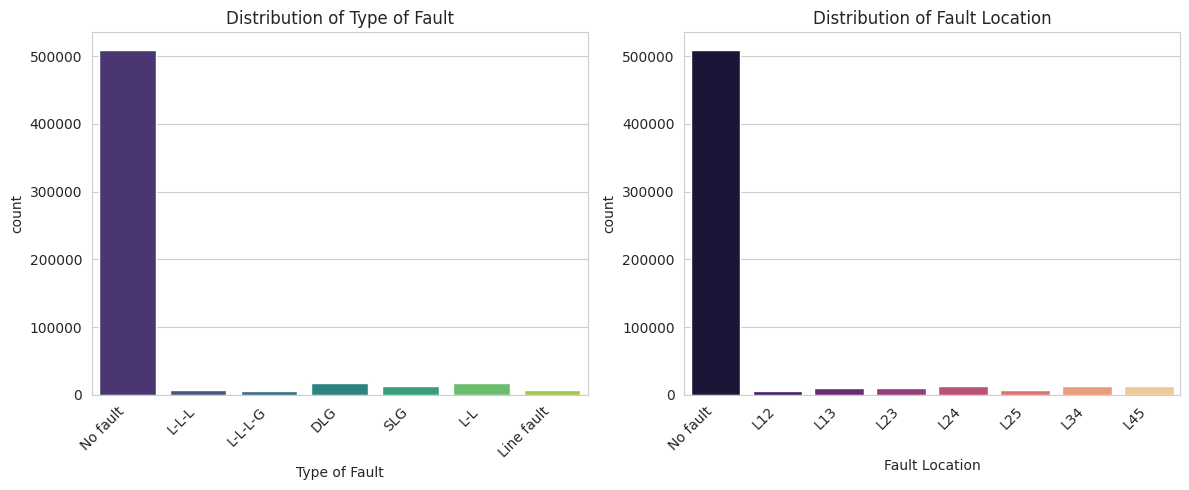

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Type of Fault', hue='Type of Fault', palette='viridis', legend=False)
plt.title('Distribution of Type of Fault')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Fault Location', hue='Fault Location', palette='magma', legend=False)
plt.title('Distribution of Fault Location')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 5.Heat Map For All The Features

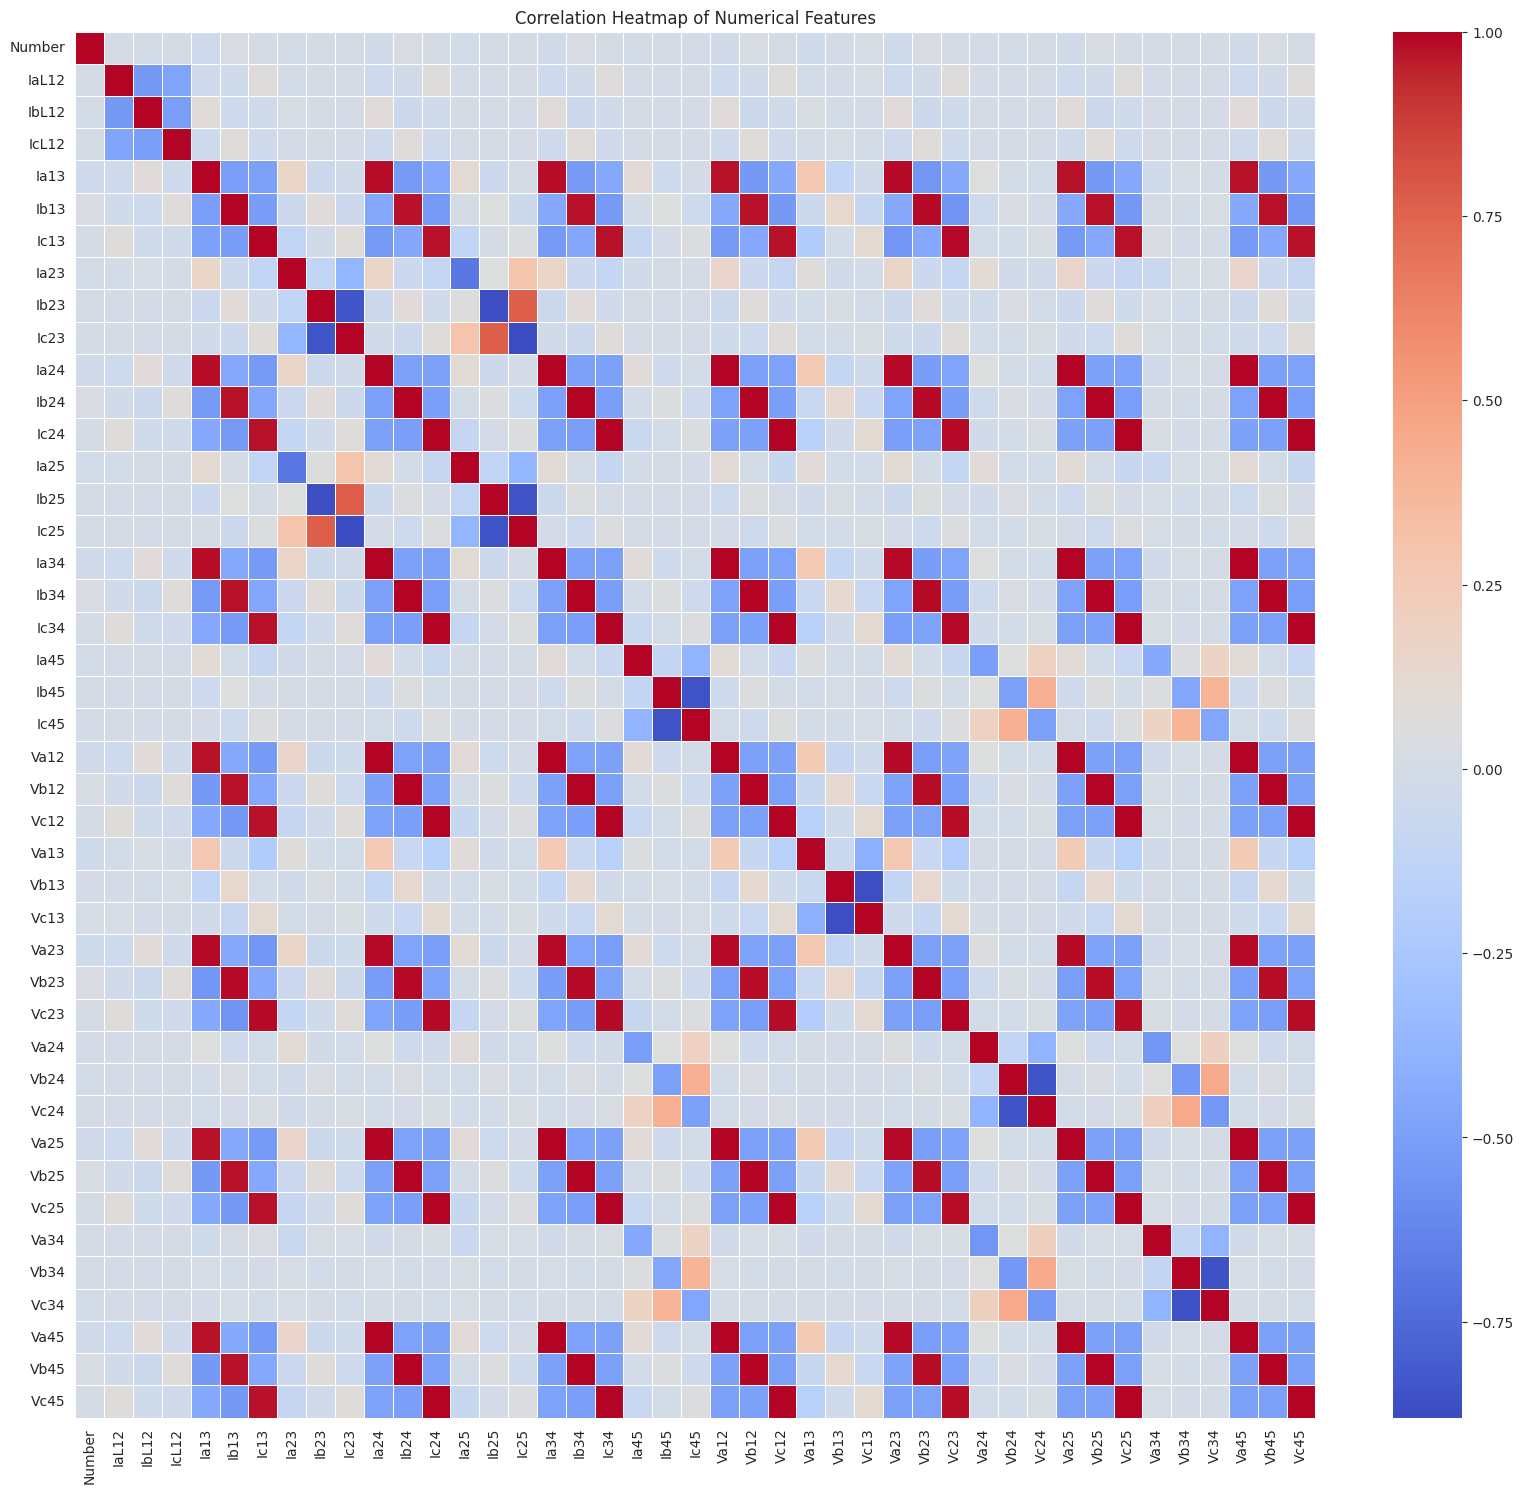

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 6.Heat Map For Top 10 Features

Top 10 features with highest overall correlation:
['Ia24', 'Ia34', 'Va23', 'Va12', 'Va25', 'Va45', 'Ia13', 'Vc23', 'Ic34', 'Ic24']


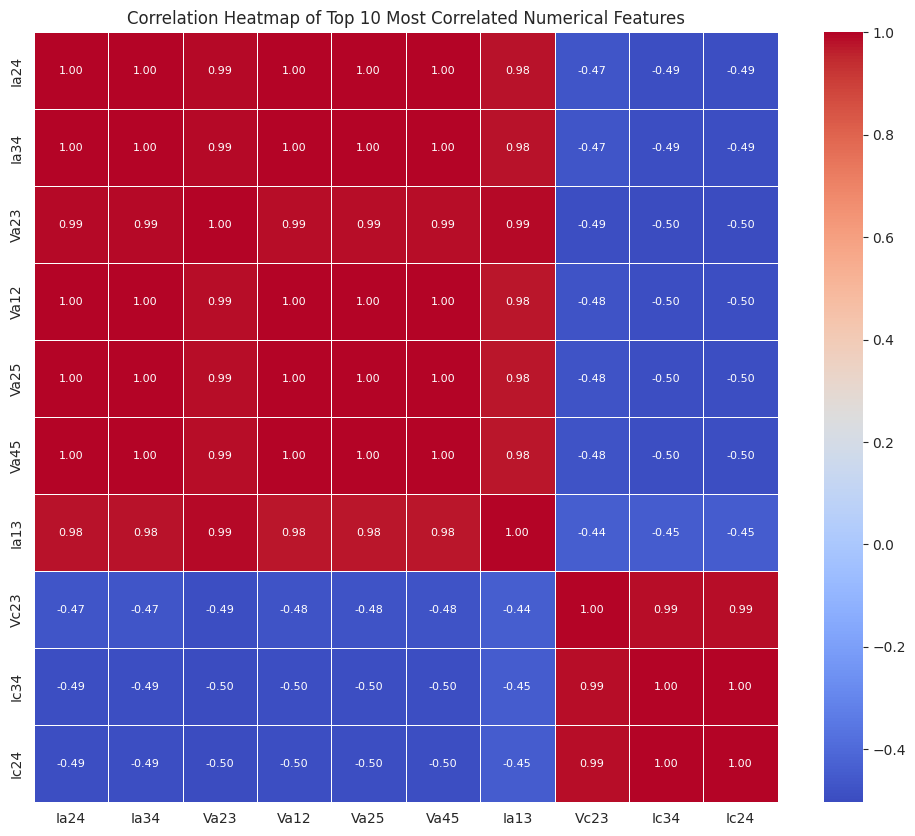

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is available if previous cells were not run in order
if 'df' not in locals():
    file_path = '/content/drive/MyDrive/TLFaultDataset.csv'
    df = pd.read_csv(file_path)

# Select numerical columns
numerical_df = df.select_dtypes(include=['float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Calculate the absolute sum of correlations for each feature
# Exclude self-correlation (which is always 1)
abs_corr_sums = correlation_matrix.abs().sum() - 1

# Get the top 10 features with the highest absolute correlation sums
top_10_features = abs_corr_sums.nlargest(10).index.tolist()

print(f"Top 10 features with highest overall correlation:\n{top_10_features}")

# Create a new correlation matrix for only the top 10 features
top_10_corr_matrix = numerical_df[top_10_features].corr()

# Set up the matplotlib figure for the top 10 features heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability

# Draw the heatmap for the top 10 features
sns.heatmap(top_10_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={
    "size": 8
})
plt.title('Correlation Heatmap of Top 10 Most Correlated Numerical Features')
plt.show()

### EDA Inference

Based on the Exploratory Data Analysis, the following key observations have been made:

1.  **Dataset Size and Completeness**: The dataset is substantial, comprising 578,923 rows and 45 columns, with no missing values. This indicates a high-quality dataset, free from immediate data imputation needs.

2.  **Data Types**: The dataset primarily consists of numerical features (43 columns of `float64`), which are likely sensor readings or other quantitative measurements. There are two categorical features (`Type of Fault` and `Fault Location`) that serve as target variables for classification tasks.

3.  **Numerical Feature Characteristics**: Descriptive statistics reveal a wide range of values and significant variance in many numerical features. This suggests that some features might require scaling or normalization during preprocessing, especially if distance-based machine learning algorithms are to be used. The presence of large standard deviations also hints at the variability within these measurements.

4.  **Target Variable Imbalance**: Both target variables, 'Type of Fault' and 'Fault Location', exhibit a severe class imbalance. The 'No fault' category overwhelmingly dominates, accounting for the vast majority of observations. For 'Type of Fault', 'DLG' and 'L-L' are the most frequent fault types, while for 'Fault Location', 'L45', 'L34', and 'L24' are more common among faulty instances. This imbalance is a critical challenge for model training, as models trained on such data can become biased towards the majority class, leading to poor performance on minority classes (the actual fault conditions).

**Implications for Modeling:**

The pronounced class imbalance will require careful handling during model development. Strategies such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, using weighted loss functions, or employing algorithms inherently robust to imbalance (e.g., tree-based models) should be considered. Furthermore, evaluation metrics like precision, recall, F1-score, and AUC-ROC, which are more informative than simple accuracy for imbalanced datasets, should be prioritized.

### 7. Applying Train And Test Split


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (moved from a previous cell to ensure df is defined)
file_path = '/content/drive/MyDrive/TLFaultDataset.csv'
df = pd.read_csv(file_path)

# Define features (X) and target (y)
# Drop 'Number' as it's likely an identifier and the target columns
X = df.drop(columns=['Number', 'Type of Fault', 'Fault Location'])
y = df['Type of Fault']

# Encode the target variable 'Type of Fault'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in original target variable:")
print(y.value_counts(normalize=True))
print("\nClass distribution in encoded target variable (training set):")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass distribution in encoded target variable (test set):")
print(pd.Series(y_test).value_counts(normalize=True))

X_train shape: (405246, 42)
X_test shape: (173677, 42)
y_train shape: (405246,)
y_test shape: (173677,)

Class distribution in original target variable:
Type of Fault
No fault      0.880521
DLG           0.030543
L-L           0.029529
SLG           0.023618
Line fault    0.013603
L-L-L         0.012530
L-L-L-G       0.009656
Name: proportion, dtype: float64

Class distribution in encoded target variable (training set):
5    0.880522
0    0.030542
1    0.029528
6    0.023618
4    0.013604
2    0.012531
3    0.009656
Name: proportion, dtype: float64

Class distribution in encoded target variable (test set):
5    0.880520
0    0.030545
1    0.029532
6    0.023619
4    0.013600
2    0.012529
3    0.009656
Name: proportion, dtype: float64


### 8. Training and Evaluating the Logistic Regression Model

Training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete.

Accuracy: 0.8806

Classification Report:
              precision    recall  f1-score   support

         DLG       0.36      0.00      0.00      5305
         L-L       0.17      0.00      0.00      5129
       L-L-L       0.27      0.00      0.00      2176
     L-L-L-G       0.04      0.00      0.00      1677
  Line fault       0.00      0.00      0.00      2362
    No fault       0.88      1.00      0.94    152926
         SLG       0.50      0.00      0.00      4102

    accuracy                           0.88    173677
   macro avg       0.32      0.14      0.13    173677
weighted avg       0.81      0.88      0.82    173677



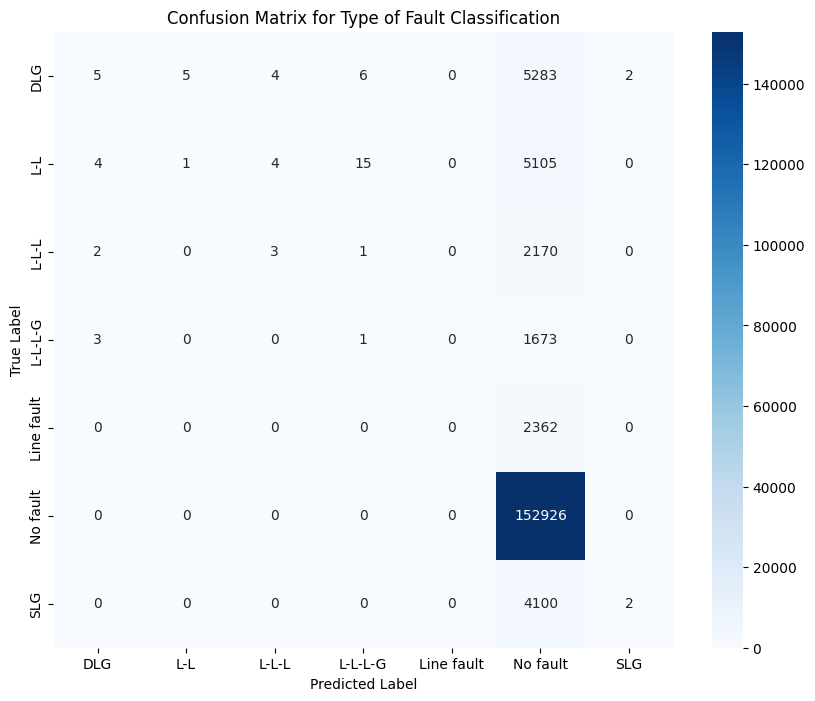


Inference from Logistic Regression:
The Logistic Regression model was trained and evaluated for 'Type of Fault' classification. 
Due to the severe class imbalance, accuracy alone might be misleading. 
Precision, Recall, and F1-score for each fault type, as shown in the classification report, 
are more critical metrics to assess the model's performance on minority classes.


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pipeline with StandardScaler and LogisticRegression
# Logistic Regression can be sensitive to feature scaling, so a StandardScaler is included.
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr', max_iter=1000))
])

# Train the model
print("Training Logistic Regression model...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
# The target names are needed for the classification report to be readable.
# Use label_encoder.classes_ to get the original class names.
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Logistic Regression:")
print("The Logistic Regression model was trained and evaluated for 'Type of Fault' classification. \nDue to the severe class imbalance, accuracy alone might be misleading. \nPrecision, Recall, and F1-score for each fault type, as shown in the classification report, \nare more critical metrics to assess the model's performance on minority classes.")

# Task
Address the class imbalance in the 'Type of Fault' training data using SMOTE, then retrain the Logistic Regression model with the balanced data and re-evaluate its performance on the test set, including new classification reports and confusion matrices, to assess improvements in fault detection.

## Apply SMOTE to Training Data

### Subtask:
Apply the Synthetic Minority Over-sampling Technique (SMOTE) to the training data (X_train, y_train) to address the class imbalance. This will generate synthetic samples for minority classes to balance their representation.


**Reasoning**:
The subtask requires applying SMOTE to the training data. This involves importing the necessary library, instantiating SMOTE, resampling the training data, and then displaying the new class distribution to confirm the application of SMOTE.



In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

# Print the new class distribution
print("\nNew class distribution after SMOTE (y_resampled):")
print(pd.Series(y_resampled).value_counts())

Shape of X_resampled: (2497796, 42)
Shape of y_resampled: (2497796,)

New class distribution after SMOTE (y_resampled):
5    356828
2    356828
6    356828
3    356828
1    356828
0    356828
4    356828
Name: count, dtype: int64


**Reasoning**:
Now that the training data has been balanced using SMOTE, the next logical step is to retrain the Logistic Regression model with this resampled data. This will involve using the previously defined `model_pipeline` and fitting it with `X_resampled` and `y_resampled`.



In [ ]:
print("Retraining Logistic Regression model with SMOTE-resampled data...")
model_pipeline.fit(X_resampled, y_resampled)
print("Retraining complete.")

Retraining Logistic Regression model with SMOTE-resampled data...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Retraining complete.


**Reasoning**:
The Logistic Regression model has been retrained with the SMOTE-resampled data. The next step is to evaluate its performance on the unseen test data. This involves making predictions on `X_test` and then generating a classification report and a confusion matrix to assess the impact of SMOTE on improving fault detection.



Making predictions on the test set with the retrained model...
Predictions complete.

Accuracy with SMOTE: 0.3140

Classification Report with SMOTE:
              precision    recall  f1-score   support

         DLG       0.07      0.04      0.05      5305
         L-L       0.19      0.05      0.08      5129
       L-L-L       0.13      0.22      0.16      2176
     L-L-L-G       0.14      0.41      0.20      1677
  Line fault       0.01      0.21      0.03      2362
    No fault       0.93      0.33      0.49    152926
         SLG       0.02      0.34      0.04      4102

    accuracy                           0.31    173677
   macro avg       0.21      0.23      0.15    173677
weighted avg       0.83      0.31      0.44    173677



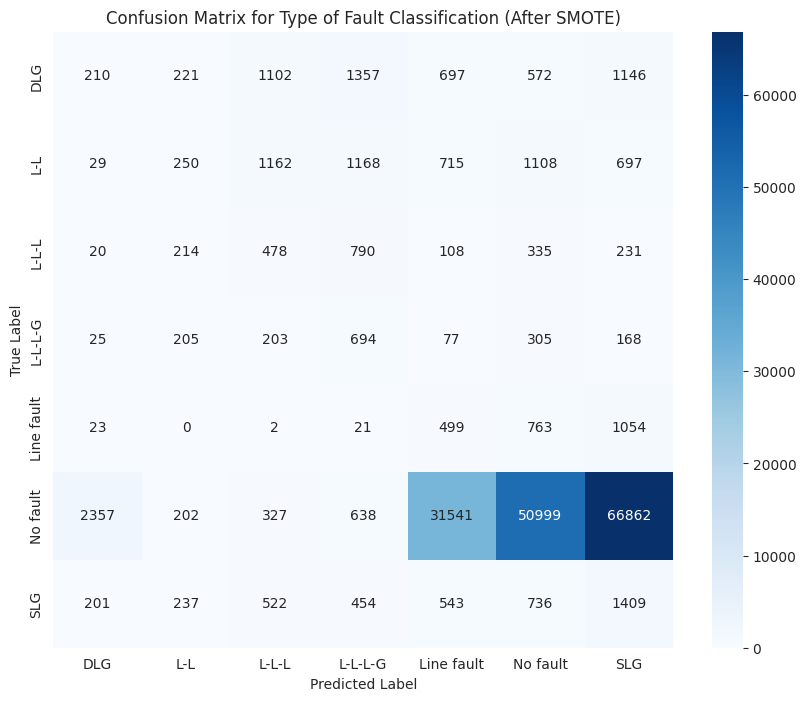


Inference after SMOTE application:
After applying SMOTE to the training data and retraining the Logistic Regression model, 
the classification report and confusion matrix will show if the model's ability to 
identify minority fault classes has improved. We expect to see higher recall and 
F1-scores for the fault types compared to the baseline model, even if overall accuracy 
might slightly decrease due to increased false positives for the majority class.


In [ ]:
print("Making predictions on the test set with the retrained model...")
y_pred_resampled = model_pipeline.predict(X_test)
print("Predictions complete.")

# Evaluate the model with resampled data
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"\nAccuracy with SMOTE: {accuracy_resampled:.4f}")

print("\nClassification Report with SMOTE:")
print(classification_report(y_test, y_pred_resampled, target_names=label_encoder.classes_))

# Plot Confusion Matrix with SMOTE
conf_matrix_resampled = confusion_matrix(y_test, y_pred_resampled)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (After SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference after SMOTE application:")
print("After applying SMOTE to the training data and retraining the Logistic Regression model, ")
print("the classification report and confusion matrix will show if the model's ability to ")
print("identify minority fault classes has improved. We expect to see higher recall and ")
print("F1-scores for the fault types compared to the baseline model, even if overall accuracy ")
print("might slightly decrease due to increased false positives for the majority class.")

### 9. Applying SVM Classifier for 'Type of Fault' Classification

Training LinearSVC model with balanced class weights...
Training complete.

Accuracy with LinearSVC: 0.8808

Classification Report for LinearSVC:
              precision    recall  f1-score   support

         DLG       0.35      0.00      0.00      5305
         L-L       0.00      0.00      0.00      5129
       L-L-L       0.27      0.02      0.04      2176
     L-L-L-G       0.09      0.04      0.06      1677
  Line fault       0.00      0.00      0.00      2362
    No fault       0.89      1.00      0.94    152926
         SLG       0.40      0.00      0.00      4102

    accuracy                           0.88    173677
   macro avg       0.29      0.15      0.15    173677
weighted avg       0.80      0.88      0.83    173677



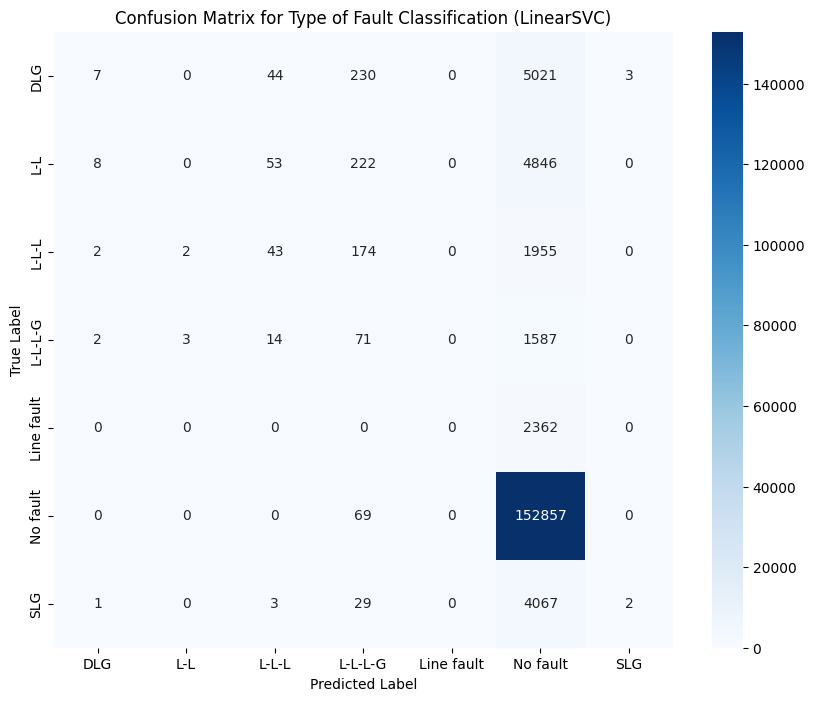


Inference from LinearSVC:
The LinearSVC model was trained and evaluated for 'Type of Fault' classification with class weights balanced. 
We will analyze the classification report and confusion matrix to see how it performs, particularly for minority classes, 
and compare it to the Logistic Regression model with and without SMOTE.


In [5]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pipeline with StandardScaler and LinearSVC
# LinearSVC is chosen for its efficiency with large datasets compared to SVC(kernel='linear')
# class_weight='balanced' is used to handle the class imbalance by automatically adjusting weights
# inversely proportional to class frequencies.
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=42, dual=False, class_weight='balanced', max_iter=10000))
])

print("Training LinearSVC model with balanced class weights...")
svm_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAccuracy with LinearSVC: {accuracy_svm:.4f}")

print("\nClassification Report for LinearSVC:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_, zero_division=0))

# Plot Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (LinearSVC)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from LinearSVC:")
print("The LinearSVC model was trained and evaluated for 'Type of Fault' classification with class weights balanced. \nWe will analyze the classification report and confusion matrix to see how it performs, particularly for minority classes, \nand compare it to the Logistic Regression model with and without SMOTE.")

### 10. Applying Random Forest Classifier for 'Type of Fault' Classification

Training Random Forest model with balanced class weights...
Training complete.

Accuracy with Random Forest: 0.9799

Classification Report for Random Forest:
              precision    recall  f1-score   support

         DLG       0.98      0.97      0.97      5305
         L-L       0.95      0.95      0.95      5129
       L-L-L       0.43      0.44      0.44      2176
     L-L-L-G       0.27      0.27      0.27      1677
  Line fault       0.92      0.91      0.92      2362
    No fault       1.00      1.00      1.00    152926
         SLG       0.98      0.96      0.97      4102

    accuracy                           0.98    173677
   macro avg       0.79      0.78      0.79    173677
weighted avg       0.98      0.98      0.98    173677



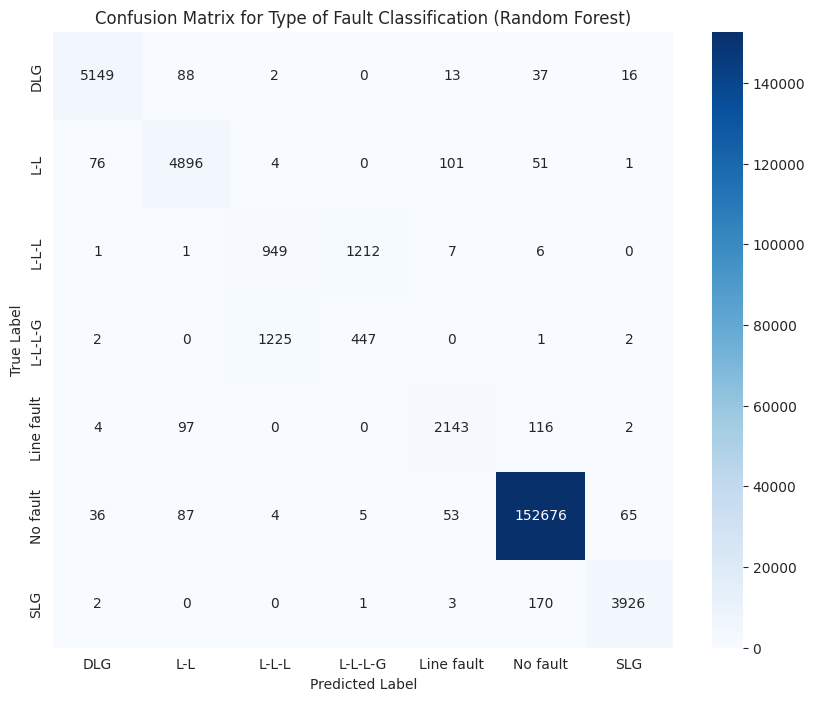


Inference from Random Forest:
The Random Forest model was trained and evaluated for 'Type of Fault' classification with class weights balanced. 
We will analyze its classification report and confusion matrix to compare its performance with previous models, especially regarding its ability to detect minority fault classes.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pipeline with StandardScaler and RandomForestClassifier
# RandomForest can handle numerical features directly, but scaling can sometimes help.
# class_weight='balanced' is used to handle the class imbalance.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1))
])

print("Training Random Forest model with balanced class weights...")
rf_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy with Random Forest: {accuracy_rf:.4f}")

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Random Forest:")
print("The Random Forest model was trained and evaluated for 'Type of Fault' classification with class weights balanced. \nWe will analyze its classification report and confusion matrix to compare its performance with previous models, especially regarding its ability to detect minority fault classes.")


### 11. Applying K-Nearest Neighbors (KNN) Classifier for 'Type of Fault' Classification

Training KNeighborsClassifier model...
Training complete.

Accuracy with KNN: 0.9688

Classification Report for KNN:
              precision    recall  f1-score   support

         DLG       0.92      0.92      0.92      5305
         L-L       0.91      0.94      0.92      5129
       L-L-L       0.45      0.44      0.44      2176
     L-L-L-G       0.30      0.30      0.30      1677
  Line fault       0.67      0.63      0.65      2362
    No fault       0.99      0.99      0.99    152926
         SLG       0.92      0.93      0.92      4102

    accuracy                           0.97    173677
   macro avg       0.74      0.74      0.74    173677
weighted avg       0.97      0.97      0.97    173677



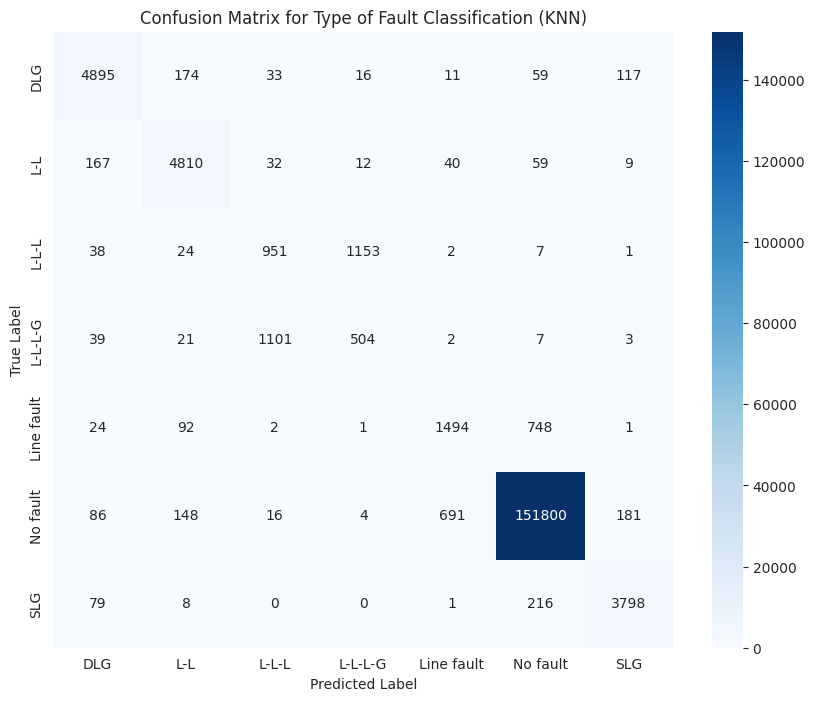


Inference from KNN:
The K-Nearest Neighbors model was trained and evaluated for 'Type of Fault' classification. 
We will examine its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
KNN's performance is highly dependent on the choice of `n_neighbors` and the effectiveness of feature scaling.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pipeline with StandardScaler and KNeighborsClassifier
# KNN is a distance-based algorithm, so feature scaling is crucial.
# We will start with a default n_neighbors (e.g., 5) and can tune it later if needed.
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)) # Using n_jobs=-1 for parallel processing
])

print("Training KNeighborsClassifier model...")
knn_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy with KNN: {accuracy_knn:.4f}")

print("\nClassification Report for KNN:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (KNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from KNN:")
print("The K-Nearest Neighbors model was trained and evaluated for 'Type of Fault' classification. ")
print("We will examine its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("KNN's performance is highly dependent on the choice of `n_neighbors` and the effectiveness of feature scaling.")


### 12. Applying Decision Tree Classifier for 'Type of Fault' Classification

Training Decision Tree model with balanced class weights...
Training complete.

Accuracy with Decision Tree: 0.9792

Classification Report for Decision Tree:
              precision    recall  f1-score   support

         DLG       0.97      0.96      0.96      5305
         L-L       0.95      0.94      0.95      5129
       L-L-L       0.50      0.51      0.50      2176
     L-L-L-G       0.35      0.34      0.34      1677
  Line fault       0.83      0.91      0.87      2362
    No fault       1.00      1.00      1.00    152926
         SLG       0.96      0.96      0.96      4102

    accuracy                           0.98    173677
   macro avg       0.79      0.80      0.80    173677
weighted avg       0.98      0.98      0.98    173677



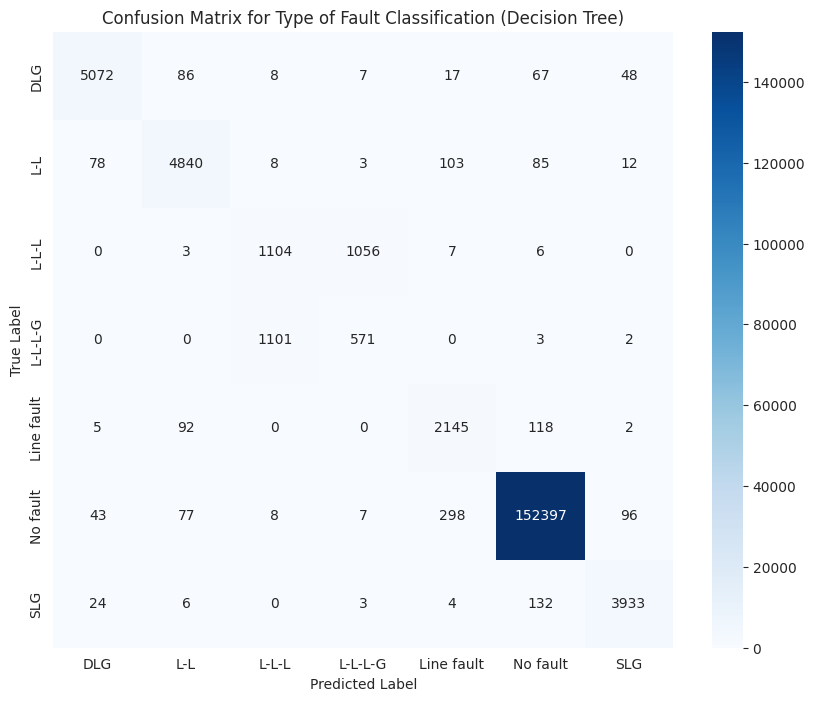


Inference from Decision Tree:
The Decision Tree model was trained and evaluated for 'Type of Fault' classification with class weights balanced. 
We will analyze the classification report and confusion matrix to see how it performs, particularly for minority classes, 
and compare it to the previous models.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pipeline with StandardScaler and DecisionTreeClassifier
# Decision Tree can be sensitive to feature scaling, though less so than linear models.
# class_weight='balanced' is used to handle the class imbalance by automatically adjusting weights.
dtc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dtc', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

print("Training Decision Tree model with balanced class weights...")
dtc_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_dtc = dtc_pipeline.predict(X_test)

# Evaluate the model
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"\nAccuracy with Decision Tree: {accuracy_dtc:.4f}")

print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dtc, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_dtc, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (Decision Tree)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Decision Tree:")
print("The Decision Tree model was trained and evaluated for 'Type of Fault' classification with class weights balanced. \nWe will analyze the classification report and confusion matrix to see how it performs, particularly for minority classes, \nand compare it to the previous models.")

### Visualizing the Decision Tree

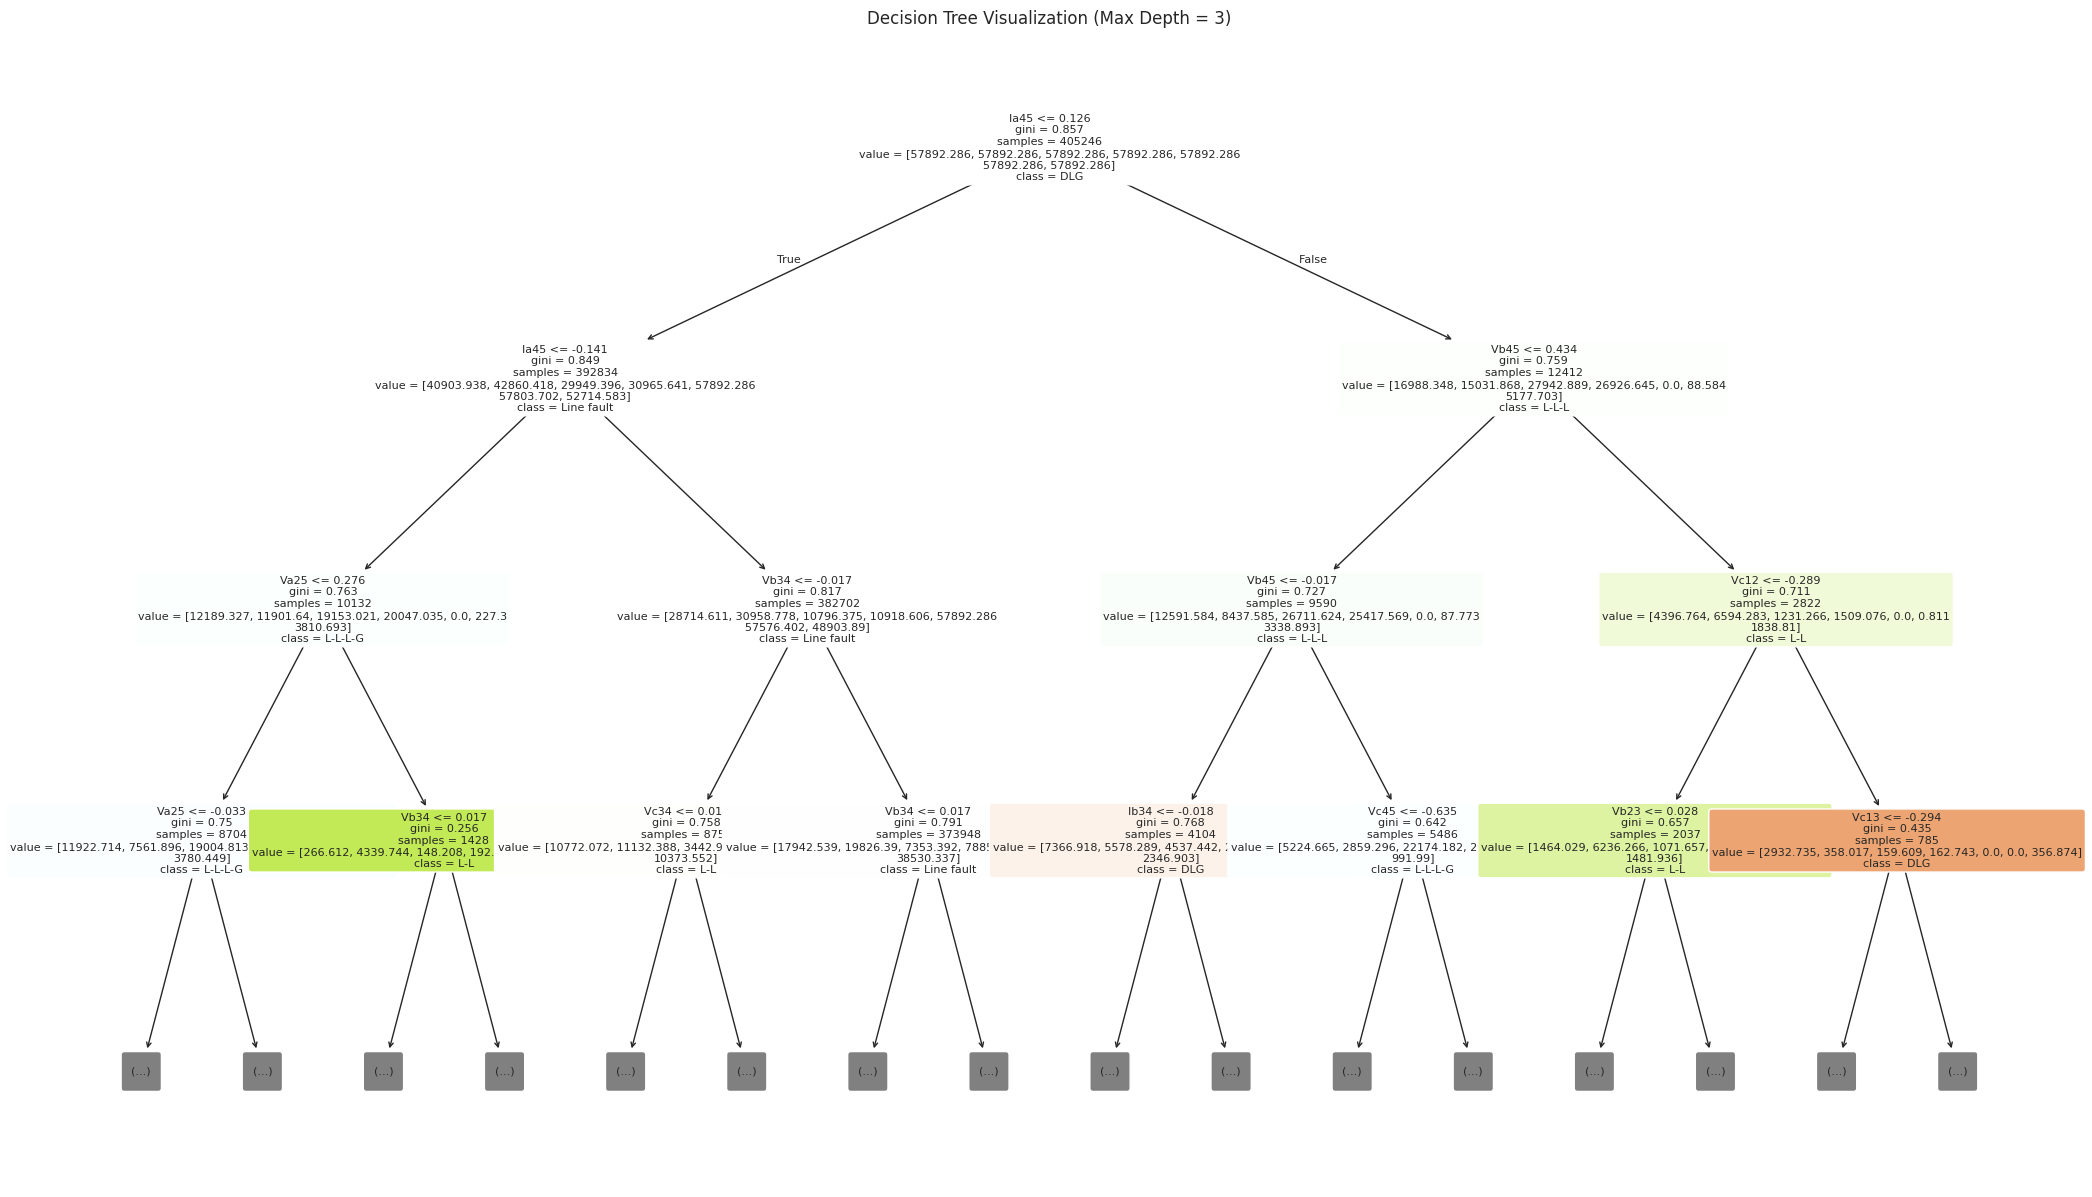

Note: This visualization is limited to a maximum depth of 3 for better interpretability. For very deep trees, the full visualization can be hard to interpret completely without zooming in. This gives an idea of the tree structure and key splitting features.


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract the DecisionTreeClassifier from the pipeline
decision_tree_model = dtc_pipeline.named_steps['dtc']

# Get feature names from X_train
feature_names = X_train.columns.tolist()

# Get class names from the label_encoder
class_names = label_encoder.classes_.tolist()

plt.figure(figsize=(25, 15))
plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()

print("Note: This visualization is limited to a maximum depth of 3 for better interpretability. For very deep trees, the full visualization can be hard to interpret completely without zooming in. This gives an idea of the tree structure and key splitting features.")

In [ ]:
# Extract the feature index of the root node (node 0)
root_node_feature_index = decision_tree_model.tree_.feature[0]

# Get the name of the feature from the feature_names list
root_node_feature_name = feature_names[root_node_feature_index]

print(f"The parameter selected as the root node is: {root_node_feature_name}")

The parameter selected as the root node is: Ia45


### 13. Applying AdaBoost Classifier for 'Type of Fault' Classification

Training AdaBoost Classifier model...
Training complete.

Accuracy with AdaBoost: 0.9798

Classification Report for AdaBoost:
              precision    recall  f1-score   support

         DLG       0.98      0.97      0.98      5305
         L-L       0.95      0.96      0.95      5129
       L-L-L       0.43      0.41      0.42      2176
     L-L-L-G       0.28      0.30      0.29      1677
  Line fault       0.88      0.92      0.90      2362
    No fault       1.00      1.00      1.00    152926
         SLG       0.97      0.98      0.98      4102

    accuracy                           0.98    173677
   macro avg       0.78      0.79      0.79    173677
weighted avg       0.98      0.98      0.98    173677



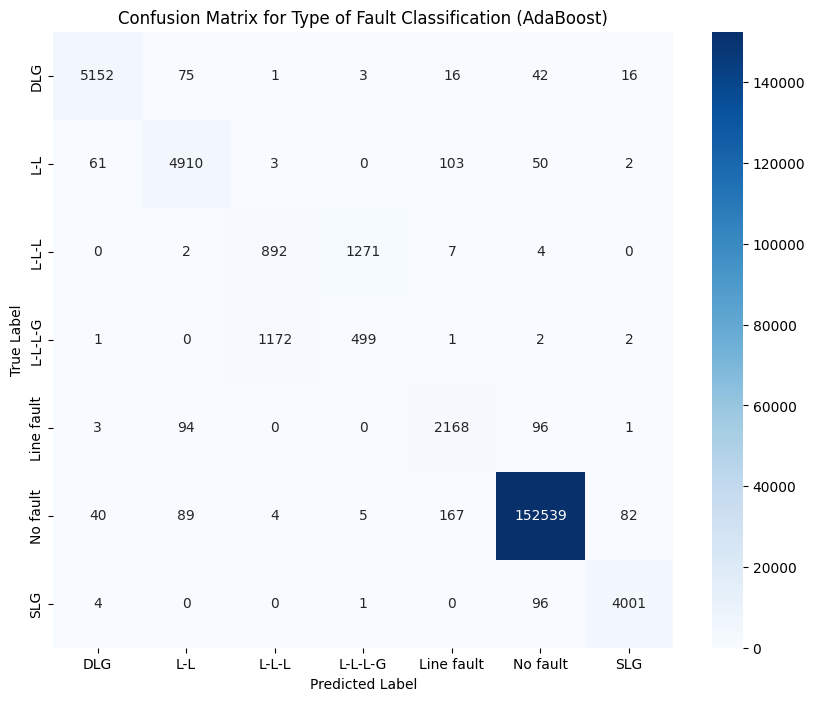


Inference from AdaBoost:
The AdaBoost Classifier model was trained and evaluated for 'Type of Fault' classification. 
We will analyze its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
AdaBoost's iterative nature and combination with a weighted base estimator are expected to yield interesting results.


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier # AdaBoost often uses Decision Trees as base estimators
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-load data and split it to ensure X_train, y_train are available
# This section is added to prevent NameError if previous cells are not executed.
file_path = '/content/drive/MyDrive/TLFaultDataset.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['Number', 'Type of Fault', 'Fault Location'])
y = df['Type of Fault']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Create a pipeline with StandardScaler and AdaBoostClassifier
# AdaBoost's base estimator can be specified. Default is a DecisionTreeClassifier.
# For imbalanced datasets, passing class_weight='balanced' to the base estimator (Decision Tree) is crucial.
# However, AdaBoost itself does not directly handle class_weight for multi-class, it passes it to the base estimator.
# Let's start without explicit class_weight in AdaBoost itself, relying on its boosting mechanism
# but using class_weight in the base estimator if we choose to define one explicitly.

# Let's use a shallow Decision Tree as the base estimator for AdaBoost
# Increasing max_depth to allow the base estimator to learn more complex patterns
# which should prevent it from performing worse than random.
base_estimator = DecisionTreeClassifier(max_depth=30, random_state=42, class_weight='balanced') # Set max_depth to 30

adaboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('adaboost', AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42))
])

print("Training AdaBoost Classifier model...")
adaboost_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_ada = adaboost_pipeline.predict(X_test)

# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"\nAccuracy with AdaBoost: {accuracy_ada:.4f}")

print("\nClassification Report for AdaBoost:")
print(classification_report(y_test, y_pred_ada, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_ada = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_ada, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (AdaBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from AdaBoost:")
print("The AdaBoost Classifier model was trained and evaluated for 'Type of Fault' classification. ")
print("We will analyze its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("AdaBoost's iterative nature and combination with a weighted base estimator are expected to yield interesting results.")

### 14. Applying Gradient Boosting Classifier for 'Type of Fault' Classification

Training Gradient Boosting Classifier model...
Training complete.

Accuracy with Gradient Boosting Classifier: 0.9540

Classification Report for Gradient Boosting Classifier:
              precision    recall  f1-score   support

         DLG       0.87      0.82      0.84      5305
         L-L       0.86      0.79      0.83      5129
       L-L-L       0.56      0.53      0.54      2176
     L-L-L-G       0.44      0.41      0.43      1677
  Line fault       0.58      0.07      0.13      2362
    No fault       0.97      1.00      0.98    152926
         SLG       0.87      0.67      0.76      4102

    accuracy                           0.95    173677
   macro avg       0.74      0.61      0.64    173677
weighted avg       0.95      0.95      0.95    173677



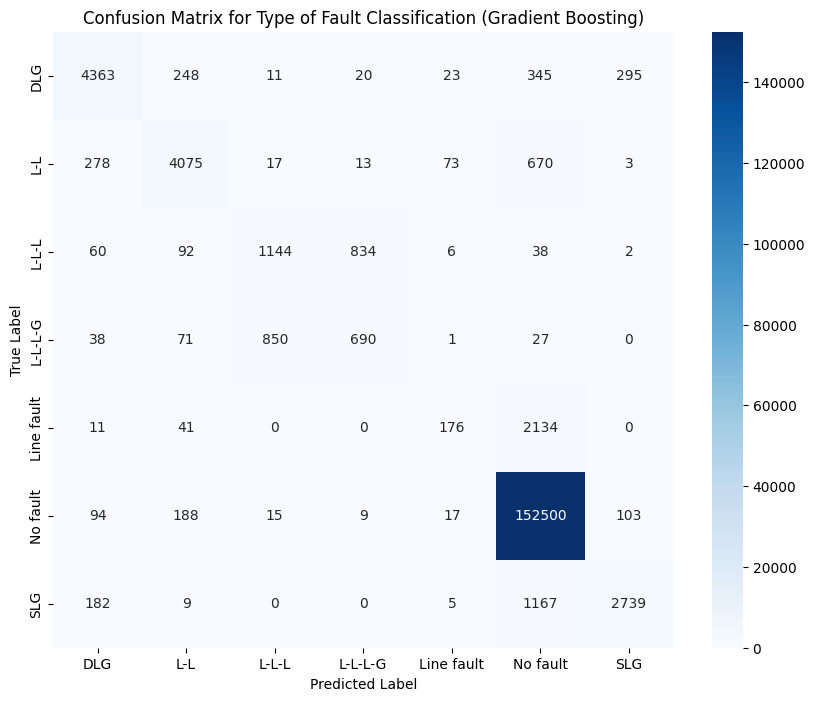


Inference from Gradient Boosting Classifier:
The Gradient Boosting Classifier model was trained and evaluated for 'Type of Fault' classification. 
We will analyze its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
Gradient Boosting is known for its strong predictive power and often performs well on tabular data.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pipeline with StandardScaler and GradientBoostingClassifier
# Gradient Boosting does not have a direct `class_weight` parameter for multi-class problems.
# It's generally recommended to handle imbalance through techniques like oversampling/undersampling
# or adjusting sample weights in the `fit` method (which is more complex for multi-class).
# For now, let's observe its performance without explicit imbalance handling in the model itself,
# relying on the boosting mechanism.

gbc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gbc', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

print("Training Gradient Boosting Classifier model...")
gbc_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_gbc = gbc_pipeline.predict(X_test)

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
print(f"\nAccuracy with Gradient Boosting Classifier: {accuracy_gbc:.4f}")

print("\nClassification Report for Gradient Boosting Classifier:")
print(classification_report(y_test, y_pred_gbc, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_gbc = confusion_matrix(y_test, y_pred_gbc)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (Gradient Boosting)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Gradient Boosting Classifier:")
print("The Gradient Boosting Classifier model was trained and evaluated for 'Type of Fault' classification. ")
print("We will analyze its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("Gradient Boosting is known for its strong predictive power and often performs well on tabular data.")


### 15. Applying Naive Bayes Classifier for 'Type of Fault' Classification

Training Naive Bayes Classifier model...
Training complete.

Accuracy with Naive Bayes: 0.6623

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

         DLG       0.36      0.04      0.07      5305
         L-L       0.37      0.11      0.17      5129
       L-L-L       0.54      0.52      0.53      2176
     L-L-L-G       0.29      0.09      0.14      1677
  Line fault       0.02      0.35      0.04      2362
    No fault       0.97      0.72      0.82    152926
         SLG       0.23      0.63      0.34      4102

    accuracy                           0.66    173677
   macro avg       0.39      0.35      0.30    173677
weighted avg       0.89      0.66      0.75    173677



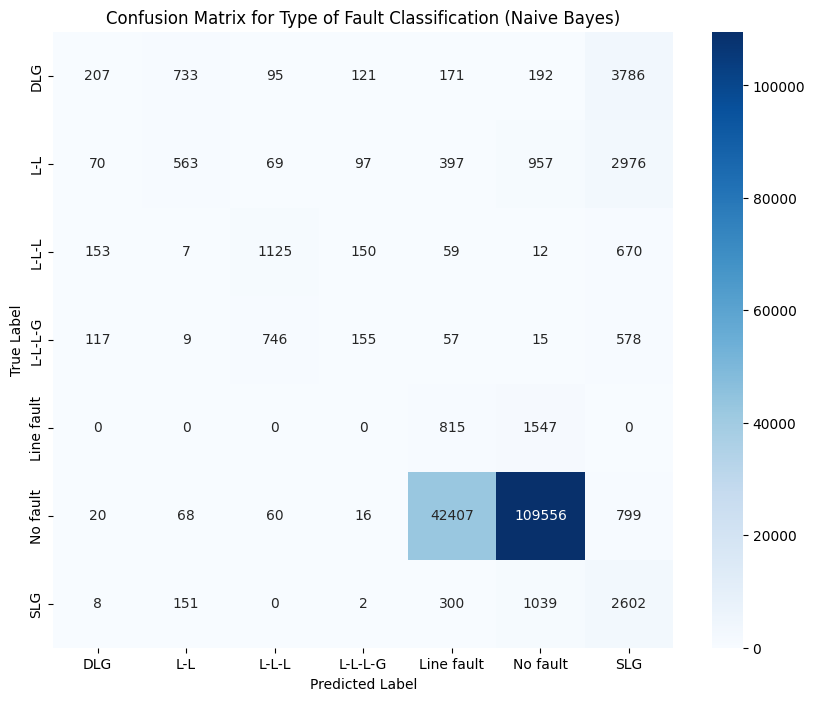


Inference from Naive Bayes:
The Naive Bayes Classifier model was trained and evaluated for 'Type of Fault' classification. 
We will analyze its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
Naive Bayes, while simple, can be effective and fast, but its assumption of feature independence might affect performance.


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pipeline with StandardScaler and GaussianNB
# GaussianNB assumes features are normally distributed, and StandardScaler helps in meeting this assumption.
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gnb', GaussianNB())
])

print("Training Naive Bayes Classifier model...")
nb_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_nb = nb_pipeline.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuracy with Naive Bayes: {accuracy_nb:.4f}")

print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (Naive Bayes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Naive Bayes:")
print("The Naive Bayes Classifier model was trained and evaluated for 'Type of Fault' classification. ")
print("We will analyze its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("Naive Bayes, while simple, can be effective and fast, but its assumption of feature independence might affect performance.")


### 15. Applying Naive Bayes Classifier for 'Type of Fault' Classification

Training Naive Bayes Classifier model...
Training complete.

Accuracy with Naive Bayes: 0.6623

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

         DLG       0.36      0.04      0.07      5305
         L-L       0.37      0.11      0.17      5129
       L-L-L       0.54      0.52      0.53      2176
     L-L-L-G       0.29      0.09      0.14      1677
  Line fault       0.02      0.35      0.04      2362
    No fault       0.97      0.72      0.82    152926
         SLG       0.23      0.63      0.34      4102

    accuracy                           0.66    173677
   macro avg       0.39      0.35      0.30    173677
weighted avg       0.89      0.66      0.75    173677



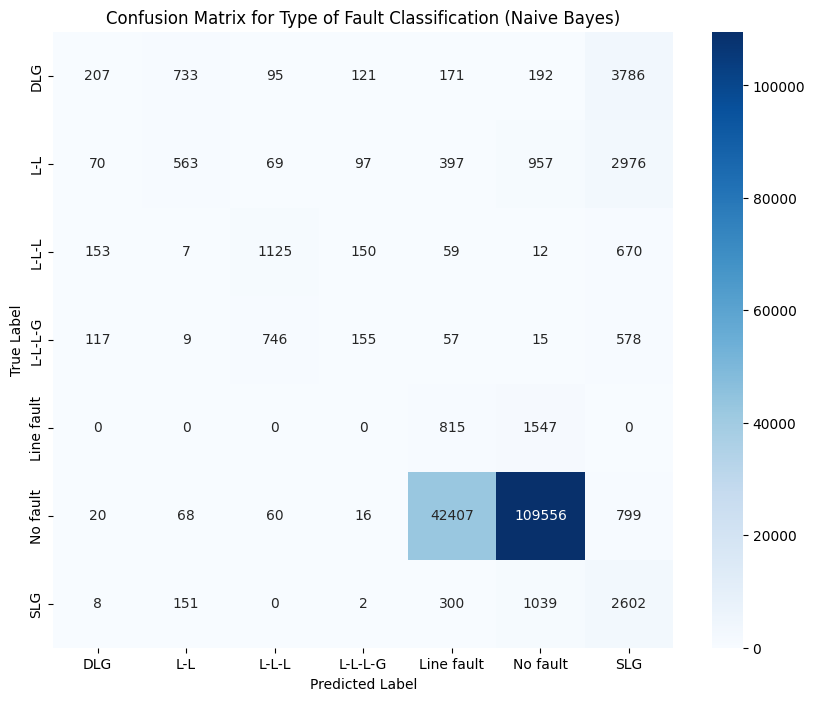


Inference from Naive Bayes:
The Naive Bayes Classifier model was trained and evaluated for 'Type of Fault' classification. 
We will analyze its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
Naive Bayes, while simple, can be effective and fast, but its assumption of feature independence might affect performance.


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pipeline with StandardScaler and GaussianNB
# GaussianNB assumes features are normally distributed, and StandardScaler helps in meeting this assumption.
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gnb', GaussianNB())
])

print("Training Naive Bayes Classifier model...")
nb_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_nb = nb_pipeline.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuracy with Naive Bayes: {accuracy_nb:.4f}")

print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (Naive Bayes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from Naive Bayes:")
print("The Naive Bayes Classifier model was trained and evaluated for 'Type of Fault' classification. ")
print("We will analyze its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("Naive Bayes, while simple, can be effective and fast, but its assumption of feature independence might affect performance.")

### 16. Applying Neural Network (MLP Classifier) for 'Type of Fault' Classification

Training MLP Classifier model...
Iteration 1, loss = 0.26332473
Iteration 2, loss = 0.16494489
Iteration 3, loss = 0.14641787
Iteration 4, loss = 0.13725812
Iteration 5, loss = 0.13276680
Iteration 6, loss = 0.12824613
Iteration 7, loss = 0.12671246
Iteration 8, loss = 0.12423667
Iteration 9, loss = 0.12234286
Iteration 10, loss = 0.12101978
Iteration 11, loss = 0.12029657
Iteration 12, loss = 0.11954620
Iteration 13, loss = 0.11875370
Iteration 14, loss = 0.11771162
Iteration 15, loss = 0.11745399
Iteration 16, loss = 0.11658608
Iteration 17, loss = 0.11594657
Iteration 18, loss = 0.11575230
Iteration 19, loss = 0.11543716
Iteration 20, loss = 0.11505161
Iteration 21, loss = 0.11413281
Iteration 22, loss = 0.11410776
Iteration 23, loss = 0.11371934
Iteration 24, loss = 0.11323807
Iteration 25, loss = 0.11258472
Iteration 26, loss = 0.11217555
Iteration 27, loss = 0.11242510
Iteration 28, loss = 0.11218966
Iteration 29, loss = 0.11153406
Iteration 30, loss = 0.11149032
Iteration 31, lo

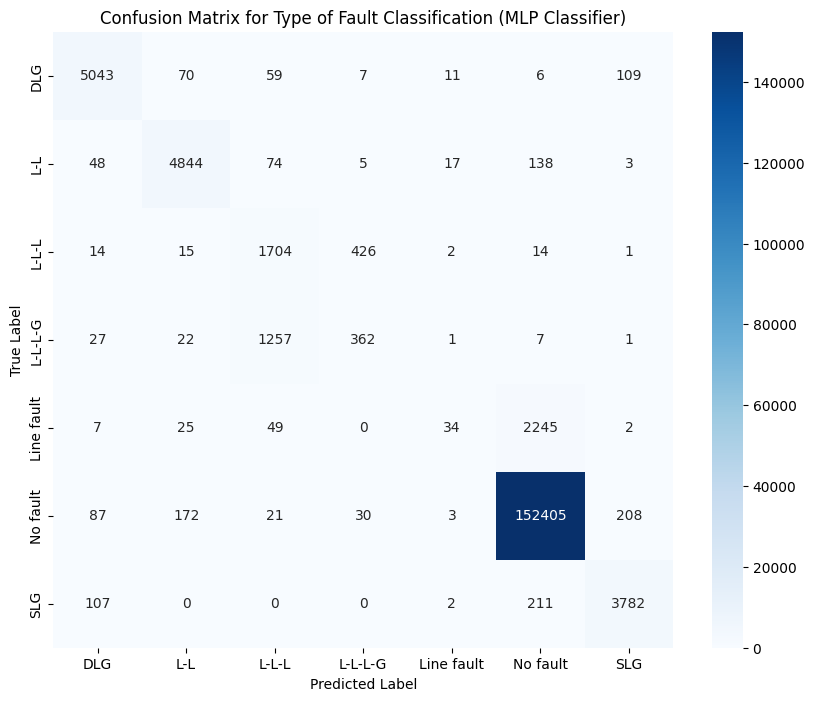


Inference from MLP Classifier:
The MLP Classifier model was trained and evaluated for 'Type of Fault' classification. 
We will analyze its classification report and confusion matrix to understand its performance, 
especially how it handles the imbalanced classes compared to previous models. 
Neural Networks are powerful for learning complex patterns, but can be sensitive to hyperparameter tuning and data preprocessing.


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a pipeline with StandardScaler and MLPClassifier
# Neural networks are highly sensitive to feature scaling, so StandardScaler is crucial.
# MLPClassifier does not have a direct class_weight parameter for multi-class classification.
# Therefore, we rely on stratified splitting and potentially consider oversampling/undersampling
# or adjusting decision thresholds if minority class performance is poor.

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, verbose=True))
])

print("Training MLP Classifier model...")
mlp_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_mlp = mlp_pipeline.predict(X_test)

# Evaluate the model
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\nAccuracy with MLP Classifier: {accuracy_mlp:.4f}")

print("\nClassification Report for MLP Classifier:")
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))

# Plot Confusion Matrix
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Type of Fault Classification (MLP Classifier)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInference from MLP Classifier:")
print("The MLP Classifier model was trained and evaluated for 'Type of Fault' classification. ")
print("We will analyze its classification report and confusion matrix to understand its performance, ")
print("especially how it handles the imbalanced classes compared to previous models. ")
print("Neural Networks are powerful for learning complex patterns, but can be sensitive to hyperparameter tuning and data preprocessing.")
